In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

import mediapipe as mp
from mediapipe.tasks.python.vision import (
    drawing_utils, drawing_styles,
    FaceDetectorOptions, FaceDetector
)

In [2]:
opt = FaceDetectorOptions(base_options=mp.tasks.BaseOptions(model_asset_path="../models/blaze_face_full_range.tflite"))
detector = FaceDetector.create_from_options(opt)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786520030.695399   65729 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [21]:
img_path = '../models/beautiful-sensual-woman-touching-her-face-isolated-white-wall-beauty-skincare-concept-spa_231208-1460.jpg'
image = mp.Image.create_from_file(img_path)
result = detector.detect(image)

In [22]:
bboxes = result.detections[0].bounding_box
start_point = (bboxes.origin_x, bboxes.origin_y)
end_point = (bboxes.origin_x + bboxes.width, bboxes.origin_y + bboxes.height)

In [ ]:
start_point, end_point

((253, 172), (449, 368))

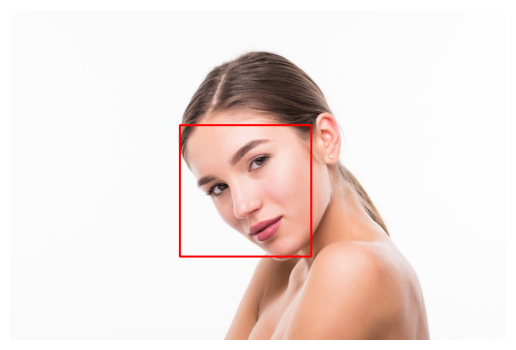

In [44]:
image_rgb = image.numpy_view().copy()
cv2.rectangle(image_rgb, start_point, end_point, (255, 0, 0), 2)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

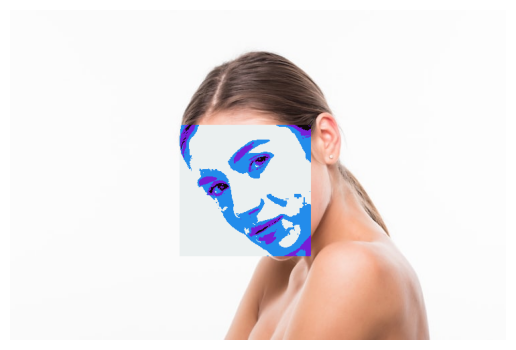

In [49]:
def filter_1(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    (x1, y1), (x2, y2) = start_point, end_point

    roi_gray = gray[y1:y2, x1:x2]
    roi_out = image_rgb[y1:y2, x1:x2]

    roi_out[roi_gray < 60] = (15, 8, 10)
    roi_out[(roi_gray >= 60) & (roi_gray < 130)] = (118, 30, 214)
    roi_out[(roi_gray >= 130) & (roi_gray < 195)] = (35, 140, 235)
    roi_out[roi_gray >= 195] = (235, 240, 240)

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_1(image)

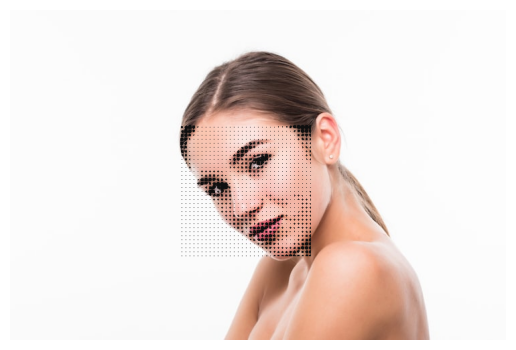

In [51]:
def filter_2(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    (x1, y1), (x2, y2) = start_point, end_point

    roi_gray = gray[y1:y2, x1:x2]
    roi_out = image_rgb[y1:y2, x1:x2]
    
    h, w = roi_gray.shape

    cell = 6
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    cx = (xx % 6) - cell / 2
    cy = (yy % 6) - cell / 2

    dist_center = np.sqrt(cx ** 2 + cy ** 2)
    radius = (1 - roi_gray / 255.0) * (cell / 1.4)
    dot_mask = dist_center < radius

    roi_out[dot_mask] = (15, 15, 15)

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_2(image)

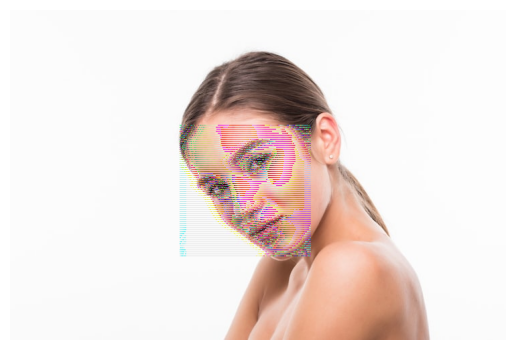

In [52]:
def filter_3(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    (x1, y1), (x2, y2) = start_point, end_point
    roi_out = image_rgb[y1:y2, x1:x2]
    
    shift = 10
    b, g, r = cv2.split(roi_out)
    r_shift = np.roll(r, -shift, axis=1)
    b_shift = np.roll(b, shift, axis=1)

    out = cv2.merge([b_shift, g, r_shift])
    roi_out[::3, :, :] = (out[::3, :, :] * 5).astype(np.uint8)

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_3(image)

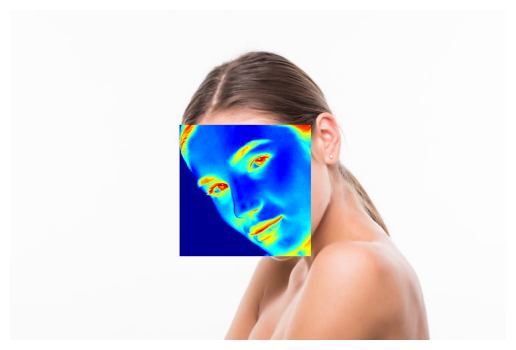

In [60]:
def filter_4(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    (x1, y1), (x2, y2) = start_point, end_point

    roi_out = image_rgb[y1:y2, x1:x2]
    roi_out = cv2.applyColorMap(roi_out, cv2.COLORMAP_JET)
    image_rgb[y1:y2, x1:x2] = roi_out

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_4(image)

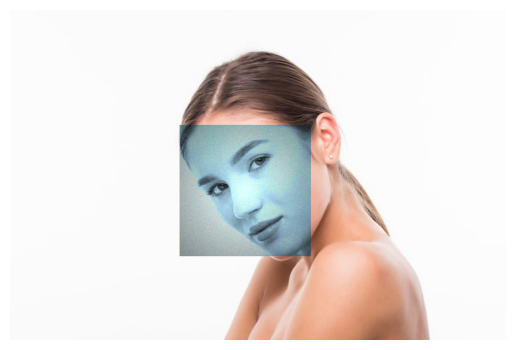

In [64]:
def filter_5(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    (x1, y1), (x2, y2) = start_point, end_point

    roi_out = image_rgb[y1:y2, x1:x2]
    h, w = roi_out.shape[:2]

    sepia_kernel = np.array(
        [
            [0.272, 0.534, 0.131],
            [0.349, 0.686, 0.168],
            [0.393, 0.769, 0.189],
        ]
    )
    sepia = cv2.transform(roi_out, sepia_kernel)
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)

    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    cy, cx = h / 2, w / 2
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    max_dist = np.sqrt(cx ** 2 + cy ** 2) or 1.0
    vignette = np.clip(1 - 0.5 * (dist / max_dist), 0, 1)[..., None]

    out = (sepia * vignette).astype(np.uint8)
    noise = np.random.randint(0, 25, out.shape, dtype=np.uint8)
    out = cv2.add(out, noise)
    image_rgb[y1:y2, x1:x2] = out

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_5(image)

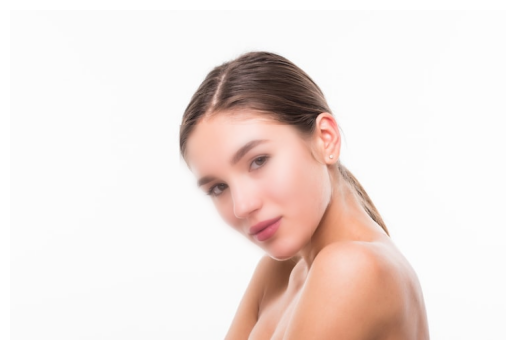

In [70]:
def filter_6(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    (x1, y1), (x2, y2) = start_point, end_point

    roi_out = image_rgb[y1:y2, x1:x2]
    blurred = cv2.GaussianBlur(roi_out, (35, 35), 0)
    roi_out = cv2.addWeighted(blurred, 0.55, roi_out, 0.45, 0.3)
    image_rgb[y1:y2, x1:x2] = roi_out

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_6(image)

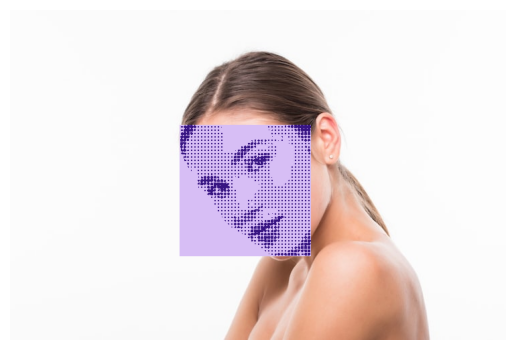

In [71]:
def filter_7(image: mp.Image):
    image_rgb = image.numpy_view().copy()
    (x1, y1), (x2, y2) = start_point, end_point

    roi_out = image_rgb[y1:y2, x1:x2]
    gray = cv2.cvtColor(roi_out, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    cell = 5

    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    cx = (xx % cell) - cell / 2
    cy = (yy % cell) - cell / 2 

    dist_center = np.sqrt(cx ** 2 + cy ** 2)
    radius = (1 - gray / 255.0) * (cell / 1.3)
    dot_mask = dist_center < radius

    roi_out = np.full_like(roi_out, (215, 190, 245))
    roi_out[dot_mask] = (55, 20, 130)
    image_rgb[y1:y2, x1:x2] = roi_out

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

result = filter_7(image)